In [2]:
#Import Libraries

In [116]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

In [117]:
from groq import Groq

In [39]:
# SET YOUR GROQ API KEY

In [118]:
client = Groq(api_key="Your_API_Key")

In [4]:
#Load Trained CNN Model

In [5]:
model = tf.keras.models.load_model("Model/plant_disease_model.h5")
print("Model loaded successfully")

Model loaded successfully


In [6]:
#Class Names

In [7]:
plants = [
'Pepper__bell___Bacterial_spot','Pepper__bell___healthy',
'Potato___Early_blight','Potato___healthy',
'Potato___Late_blight','Tomato_Bacterial_spot',
'Tomato_Early_blight','Tomato_healthy',
'Tomato_Late_blight','Tomato_Leaf_Mold',
'Tomato_Septoria_leaf_spot',
'Tomato_Spider_mites_Two_spotted_spider_mite',
'Tomato__Target_Spot',
'Tomato__Tomato_mosaic_virus',
'Tomato__Tomato_YellowLeaf__Curl_Virus'
]

In [8]:
#Upload Leaf Image

In [144]:
print("\nTesting custom image...")

# Load image
img = cv2.imread("uploadimages/1.jpg")

if img is None:
    print("Error: Image not found. Check the path.")
else:

    img = cv2.resize(img,(64,64))
    img_norm = img.astype("float32") / 255.0
    img_array = np.expand_dims(img_norm,axis=0)

    # Prediction
    preds = model(img_array, training=False).numpy()

    predicted_class = np.argmax(preds)
    confidence = np.max(preds) * 100

    predicted_label = plants[predicted_class]

    print("\nPrediction:", predicted_label)
    print("Confidence: {:.2f}%".format(confidence))

    # Check healthy vs disease
    if "healthy" in predicted_label.lower():
        print("\nResult: The leaf is HEALTHY. No disease detected.")
    else:
        print("\nResult: The leaf is DISEASED.")
        print("Detected Disease:", predicted_label)


Testing custom image...

Prediction: Pepper__bell___Bacterial_spot
Confidence: 100.00%

Result: The leaf is DISEASED.
Detected Disease: Pepper__bell___Bacterial_spot


In [145]:
#Grad-CAM Function

In [146]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    img_tensor = tf.convert_to_tensor(img_array)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output,
                 model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_tensor,training=False)

        class_index = tf.argmax(predictions[0])
        class_channel = predictions[:,class_index]

    grads = tape.gradient(class_channel,conv_outputs)

    pooled_grads = tf.reduce_mean(grads,axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads,axis=-1)

    heatmap = tf.maximum(heatmap,0)

    heatmap /= tf.reduce_max(heatmap)+1e-8

    return heatmap.numpy()

In [147]:
#Generate Grad-CAM

In [148]:
heatmap = make_gradcam_heatmap(img_array,model,"last_conv")

heatmap = cv2.resize(heatmap,(img.shape[1],img.shape[0]))

heatmap = np.uint8(255*heatmap)

heatmap = cv2.applyColorMap(heatmap,cv2.COLORMAP_JET)

gradcam_img = cv2.addWeighted(img,0.6,heatmap,0.4,0)

In [149]:
#Visual Explanation

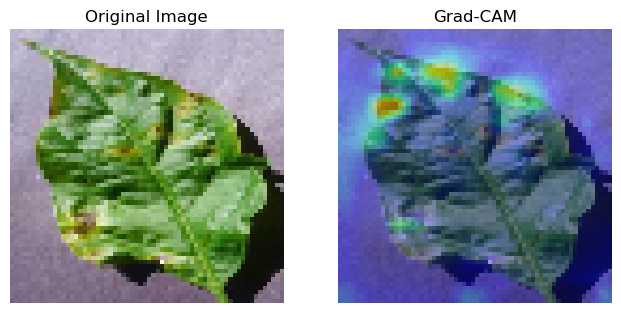

In [150]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM")
plt.imshow(cv2.cvtColor(gradcam_img,cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

In [111]:
#OpenAI Explanation Function

In [123]:
def generate_ai_explanation(disease_name):

    prompt = f"""
    You are an expert agricultural AI assistant.

    Explain the plant disease: {disease_name}

    Include:
    - What is the disease
    - Causes
    - Symptoms
    - Treatment
    - Prevention
    Keep explanation simple for farmers.
    """

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",  # Free model
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.5
    )

    return response.choices[0].message.content

In [113]:
#Generate AI Explanation

In [124]:
ai_response = generate_ai_explanation(predicted_label)
print("\n===== AI Explanation =====\n")
print(ai_response)


===== AI Explanation =====

**Pepper Bell Bacterial Spot Disease**

**What is the disease?**
Pepper Bell Bacterial Spot is a bacterial disease that affects pepper plants, specifically the bell pepper variety. It's a common problem in warm and humid climates.

**Causes**
The disease is caused by the bacterium Xanthomonas campestris pv. vesicatoria. It's spread through:

1. Water splashing from infected plants
2. Contaminated tools and equipment
3. Infested seeds or seedlings
4. Nearby infected plants

**Symptoms**
The disease causes:

1. Small, dark spots on the leaves and stems
2. Spots can merge to form larger lesions
3. Lesions can cause plant leaves to curl or distort
4. Affected areas may turn yellow or brown
5. In severe cases, the disease can cause the plant to die

**Treatment**
To treat Pepper Bell Bacterial Spot:

1. **Remove infected plants**: Cut off and dispose of infected plants to prevent the disease from spreading.
2. **Prune healthy plants**: Remove any infected areas 